# Créer des fiches pour l'analyse Poldoc

In [8]:
import pandas as pd
import datetime as dt
from os.path import join

In [9]:
lastyear = dt.datetime.today().year - 1

nref = lastyear
n1 = nref - 1
n2 = nref - 2

# Transformation en strings

nref = str(nref)
n1 = str(n1)
n2 = str(n2)

In [10]:
# listes des colonnes à aggréger

cols2keep = ['collection_code',
             #'collection_lib1',
             #'collection_lib2',
             'collection_lib3',
             'collection_lib4',
             'support'
            ]

cols2keep_WithoutSupport = ['collection_code',
                            #'collection_lib1',
                            #'collection_lib2',
                            'collection_lib3',
                            'collection_lib4']

In [11]:
vals2keep_tab1 = ['nb_exemplaires_empruntables',
                  'nb_acquisitions',
                  'nb_exemplaires_éliminés'
                 ]

vals2keep_tab2 = [f'nb_prets_{nref}',
                  f'nb_prets_{n1}',
                  f'nb_prets_{n2}',
                  f'nb_prets_{nref}_emprunteurs_distincts',
                  f'nb_prets_{n1}_emprunteurs_distincts',
                  f'nb_prets_{n2}_emprunteurs_distincts',
                  f'nb_exemplaires_empruntables',
                  f'nb_exemplaires_en_pret',
                  f'nb_prets_{nref}_exemplaires_distincts',
                  f'nb_exemplaires_empruntables_pas_empruntés_3_ans',
         ]

vals2keep_tab3 = ['nb_exemplaires_empruntables',
                  'nb_acquisitions',
                  f'nb_prets_{nref}'
                 ]

In [12]:
filepath_data = f"/home/kibini/kibini_prod/data/collections/{lastyear}_synthese.xlsx"

In [22]:
class Poldoc:
    def __init__(self,site='med'):
        
        self.df = pd.read_excel(filepath_data,sheet_name='mediatheque')
        
        if site == 'bus':
            self.df = pd.read_excel(filepath,sheet_name='zebre')
        
        if site == 'col':
            self.df = pd.read_excel(filepath_data,sheet_name='collectivites')

    def clean_dataset(self):
        """
        Une méthode pour nettoyer les valeurs du jeu de données et procéder à l'analyse
        """
        self.df = self.df[self.df['support']!='Périodique']
        
        self.df.loc[
            (self.df['collection_lib3']=='Livres précieux') &
            (self.df['collection_lib1']=='Jeunesse'),'collection_lib3'] = 'Livres précieux Petits enfants'
        
        self.df.loc[self.df['collection_lib4'].isna(),'collection_lib4'] = 'absence libellé'

        self.df.rename(columns={'nb_exemplaires_créés_dans_annee':'nb_acquisitions'},inplace=True)


    def get_tableau1(self,collection_level=None,collection_lib=None,support=True):

        if support==False:
            tab1 = self.df[self.df[collection_level].isin(collection_lib)].groupby(cols2keep_WithoutSupport)[vals2keep_tab1].sum()
        
        else:
            tab1 = self.df[self.df[collection_level].isin(collection_lib)].groupby(cols2keep)[vals2keep_tab1].sum()
    
            tab1['tx_acroissement (En %)'] = round((tab1['nb_acquisitions'] - tab1['nb_exemplaires_éliminés'])/tab1['nb_exemplaires_empruntables']*100,1)
            tab1['tx_renouvellement (En %)'] = round((tab1['nb_acquisitions'] / tab1['nb_exemplaires_empruntables'])*100,1)
        
        tab1 = tab1.T
        return(tab1)

    def get_tableau2(self,collection_level,collection_lib,support=True):
        if support == False:
            tab2 = self.df[self.df[collection_level].isin(collection_lib)].groupby(cols2keep_WithoutSupport)[vals2keep_tab2].sum()
        else:
            tab2 = self.df[self.df[collection_level].isin(collection_lib)].groupby(cols2keep)[vals2keep_tab2].sum()

        tab2[f'evolution_prets_{n2}-{nref} (En %)'] = round((tab2[f"nb_prets_{nref}"] - tab2[f'nb_prets_{n2}'])/tab2[f'nb_prets_{n2}']*100,1)
        tab2[f'evolution_prets_{n1}-{nref} (En %)'] = round((tab2[f"nb_prets_{nref}"] - tab2[f'nb_prets_{n1}'])/tab2[f'nb_prets_{n1}']*100,1)
        
        tab2[f'evolution_prets_emprunteurs_distincts_{n2}-{nref} (En %)'] = round((tab2[f'nb_prets_{nref}_emprunteurs_distincts'] - tab2[f'nb_prets_{n2}_emprunteurs_distincts']) / tab2[f'nb_prets_{n2}_emprunteurs_distincts']*100,1)
        tab2[f'evolution_prets_emprunteurs_distincts_{n1}-{nref} (En %)'] = round((tab2[f'nb_prets_{nref}_emprunteurs_distincts'] - tab2[f'nb_prets_{n1}_emprunteurs_distincts']) / tab2[f'nb_prets_{n1}_emprunteurs_distincts']*100,1)
        
        tab2['tx_rotation'] = (tab2[f'nb_prets_{nref}'] / tab2['nb_exemplaires_empruntables']).round(1)
        tab2['tx_sortie (En %)'] = (tab2['nb_exemplaires_en_pret'] / tab2['nb_exemplaires_empruntables']*100).round(1)
        tab2['tx_fonds_actifs (En %)'] = (tab2[f'nb_prets_{nref}_exemplaires_distincts'] / tab2['nb_exemplaires_empruntables']*100).round(1)
        tab2['Part de docs pas empruntés depuis 3 ans (En %)'] = (tab2['nb_exemplaires_empruntables_pas_empruntés_3_ans'] / tab2['nb_exemplaires_empruntables']*100).round(1)
        
        # Tri dans l'ordre souhaité
        tab2 = tab2[[f'nb_prets_{n1}',
        f'nb_prets_{n2}',
        f'nb_prets_{nref}',
        f'evolution_prets_{n2}-{nref} (En %)',
        f'evolution_prets_{n1}-{nref} (En %)',
        f'nb_prets_{nref}_emprunteurs_distincts',
        f'evolution_prets_emprunteurs_distincts_{n2}-{nref} (En %)',
        f'evolution_prets_emprunteurs_distincts_{n1}-{nref} (En %)',
        'tx_rotation',
        'tx_fonds_actifs (En %)','Part de docs pas empruntés depuis 3 ans (En %)']]
        
        tab2 = tab2.T
        return(tab2)

        
    def get_tableau3(self,secteur,collection_level,collection_lib):
        tab3 = self.df[self.df[collection_level].isin(collection_lib)]

        tab3 = tab3.pivot_table(index=collection_level,
                                values=vals2keep_tab3,
                                aggfunc=sum
                               )
        tab3 = tab3.T

        # Ajout du total par ligne
        tab3.loc[tab3.index=='nb_acquisitions',f'Total_secteur_{secteur}'] = self.df[self.df['collection_lib1']==secteur]['nb_acquisitions'].sum()
        tab3.loc[tab3.index=='nb_exemplaires_empruntables',f'Total_secteur_{secteur}'] = self.df[self.df['collection_lib1']==secteur]['nb_exemplaires_empruntables'].sum()
        tab3.loc[tab3.index==f'nb_prets_{nref}',f'Total_secteur_{secteur}'] = self.df[self.df['collection_lib1']==secteur][f'nb_prets_{nref}'].sum()


        # Ajout de la part en %
        #tab3['Total_collections'] = tab3[collection_lib].sum(axis=1)
        tab3[f'Part collection {collection_lib} sur Total_{secteur} (En %)'] = round(tab3[collection_lib].sum(axis=1) / tab3[f'Total_secteur_{secteur}']*100,1)
     
        return(tab3)


In [23]:
df = Poldoc()
df.clean_dataset()
df.get_tableau1(collection_level='collection_lib3',
                collection_lib=['Arts et loisirs créatifs'],
                #support=False
               )

collection_code                              AAPATAP          \
collection_lib3             Arts et loisirs créatifs           
collection_lib4                                 Arts           
support                                          DVD   Livre   
nb_exemplaires_empruntables                    201.0  2170.0   
nb_acquisitions                                  7.0    74.0   
nb_exemplaires_éliminés                          0.0    26.0   
tx_acroissement (En %)                           3.5     2.2   
tx_renouvellement (En %)                         3.5     3.4   

collection_code                              AAPATLC         
collection_lib3             Arts et loisirs créatifs         
collection_lib4                     Loisirs créatifs         
support                                          DVD  Livre  
nb_exemplaires_empruntables                     10.0  601.0  
nb_acquisitions                                  2.0   53.0  
nb_exemplaires_éliminés                          0.0    8.0  
tx_acroissement (En %)                          20.0    7.5  
tx_renouvellement (En %)                        20.0    8.8

collection_code                              AAPATAP          \
collection_lib3             Arts et loisirs créatifs           
collection_lib4                                 Arts           
support                                          DVD   Livre   
nb_exemplaires_empruntables                    201.0  2170.0   
nb_acquisitions                                  7.0    74.0   
nb_exemplaires_éliminés                          0.0    26.0   
tx_acroissement (En %)                           3.5     2.2   
tx_renouvellement (En %)                         3.5     3.4   

collection_code                              AAPATLC         
collection_lib3             Arts et loisirs créatifs         
collection_lib4                     Loisirs créatifs         
support                                          DVD  Livre  
nb_exemplaires_empruntables                     10.0  601.0  
nb_acquisitions                                  2.0   53.0  
nb_exemplaires_éliminés                          0.0    8.0  
tx_acroissement (En %)                          20.0    7.5  
tx_renouvellement (En %)                        20.0    8.8

In [18]:
df.get_tableau2(collection_level='collection_lib3',
                collection_lib=['Arts et loisirs créatifs'],
                #support=False
               )

collection_code                                                     AAPATAP  \
collection_lib3                                    Arts et loisirs créatifs   
collection_lib4                                                        Arts   
support                                                                 DVD   
nb_prets_2023                                                          98.0   
nb_prets_2022                                                          95.0   
nb_prets_2024                                                         116.0   
evolution_prets_2022-2024 (En %)                                       22.1   
evolution_prets_2023-2024 (En %)                                       18.4   
nb_prets_2024_emprunteurs_distincts                                    70.0   
evolution_prets_emprunteurs_distincts_2022-2024...                     25.0   
evolution_prets_emprunteurs_distincts_2023-2024...                     55.6   
tx_rotation                                                             0.6   
tx_fonds_actifs (En %)                                                 32.8   
Part de docs pas empruntés depuis 3 ans (En %)                         34.8   

collection_code                                             \
collection_lib3                                              
collection_lib4                                              
support                                              Livre   
nb_prets_2023                                       1607.0   
nb_prets_2022                                       1531.0   
nb_prets_2024                                       1511.0   
evolution_prets_2022-2024 (En %)                      -1.3   
evolution_prets_2023-2024 (En %)                      -6.0   
nb_prets_2024_emprunteurs_distincts                  558.0   
evolution_prets_emprunteurs_distincts_2022-2024...     0.5   
evolution_prets_emprunteurs_distincts_2023-2024...     1.8   
tx_rotation                                            0.7   
tx_fonds_actifs (En %)                                36.1   
Part de docs pas empruntés depuis 3 ans (En %)        30.9   

collection_code                                                     AAPATLC  \
collection_lib3                                    Arts et loisirs créatifs   
collection_lib4                                            Loisirs créatifs   
support                                                                 DVD   
nb_prets_2023                                                          16.0   
nb_prets_2022                                                          32.0   
nb_prets_2024                                                          30.0   
evolution_prets_2022-2024 (En %)                                       -6.2   
evolution_prets_2023-2024 (En %)                                       87.5   
nb_prets_2024_emprunteurs_distincts                                    27.0   
evolution_prets_emprunteurs_distincts_2022-2024...                     17.4   
evolution_prets_emprunteurs_distincts_2023-2024...                     80.0   
tx_rotation                                                             3.0   
tx_fonds_actifs (En %)                                                 70.0   
Part de docs pas empruntés depuis 3 ans (En %)                         10.0   

collection_code                                             
collection_lib3                                             
collection_lib4                                             
support                                              Livre  
nb_prets_2023                                       1283.0  
nb_prets_2022                                       1116.0  
nb_prets_2024                                       1554.0  
evolution_prets_2022-2024 (En %)                      39.2  
evolution_prets_2023-2024 (En %)                      21.1  
nb_prets_2024_emprunteurs_distincts                  425.0  
evolution_prets_emprunteurs_distincts_2022-2024...    20.1  
evolution_prets_emprunteur

In [19]:
df.get_tableau3(secteur='Adultes',collection_level='collection_lib3',collection_lib=['Arts et loisirs créatifs'])

collection_lib3,Arts et loisirs créatifs,Total_secteur_Adultes,Part collection ['Arts et loisirs créatifs'] sur Total_Adultes (En %)
nb_acquisitions,156.0,4848.0,3.2
nb_exemplaires_empruntables,3020.0,122892.0,2.5
nb_prets_2024,3303.0,137902.0,2.4


# CREER DES FICHES DE POLDOC PROPRES
Créer un paramètre pour sauvegarder la fiche au format word
Créer un paramètre pour sauvegarer la fiche au format Excel

OU

Créer une nouvelle méthode qui permet de récupérer les 3 tableaux générés et les enregistrer dans un doc word ? (éviterait de répéter le même script pour chaque tableau)

In [45]:
df_test = df.get_tableau3(secteur='Adultes',
                          collection_level='collection_lib3',collection_lib=['Arts et loisirs créatifs'],
                          #support=False
                         )

C:\Users\chirliasl\AppData\Local\Temp\ipykernel_10476\3999513633.py:77: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  tab3 = tab3.pivot_table(index=collection_level,


In [46]:
df_test

collection_lib3,Arts et loisirs créatifs,Total_secteur_Adultes,Part collection ['Arts et loisirs créatifs'] sur Total_Adultes (En %)
nb_acquisitions,156.0,4848.0,3.2
nb_exemplaires_empruntables,3020.0,122892.0,2.5
nb_prets_2024,3303.0,137902.0,2.4


In [47]:
df_display = df_test.reset_index(names='indicateur')
df_display

collection_lib3,indicateur,Arts et loisirs créatifs,Total_secteur_Adultes,Part collection ['Arts et loisirs créatifs'] sur Total_Adultes (En %)
0,nb_acquisitions,156.0,4848.0,3.2
1,nb_exemplaires_empruntables,3020.0,122892.0,2.5
2,nb_prets_2024,3303.0,137902.0,2.4


In [48]:
df_display.columns = [
    " - ".join([str(x) for x in col if x]) if isinstance(col, tuple) else col
    for col in df_display.columns
]
df_display

,indicateur,Arts et loisirs créatifs,Total_secteur_Adultes,Part collection ['Arts et loisirs créatifs'] sur Total_Adultes (En %)
0,nb_acquisitions,156.0,4848.0,3.2
1,nb_exemplaires_empruntables,3020.0,122892.0,2.5
2,nb_prets_2024,3303.0,137902.0,2.4


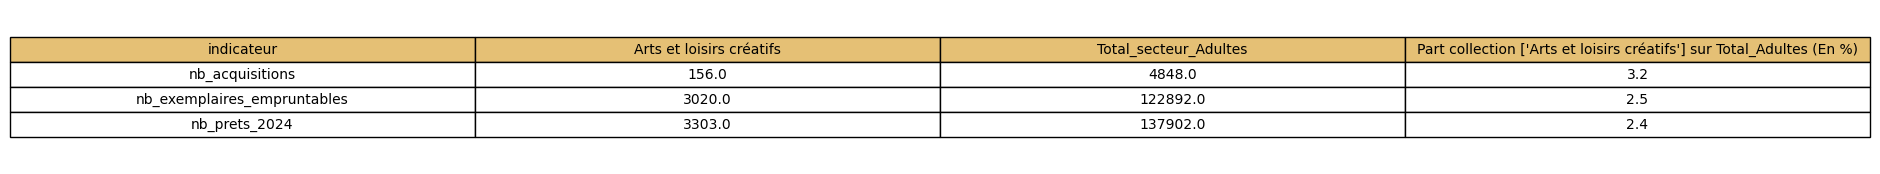

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
# Créer une figure vide
fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')  # cacher axes

# Ajouter le DataFrame comme table
table = ax.table(cellText=df_display.values,
                 colLabels=df_display.columns,
                 colColours=["#e5c075","#e5c075","#e5c075","#e5c075"],
                 #cellText=df_test.values,
                 #colLabels=df_test.columns,
                 loc='center',
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(3, 1.5)  # largeur/hauteur cellules


# Sauvegarder en image
plt.savefig(join("resultats",'image_test'),
            bbox_inches='tight',
            #dpi=50
           )

plt.show()
plt.close()
